# Function 5 Analysis - Week 2

This notebook contains the exploratory analysis for **Function 5** in Week 2. We continue to focus on an exploitation strategy around the best observed peak, now with **21 datapoints** after adding last week’s measurement.

**Function Description:** 	
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

## Loading and Displaying the Data

We load the inputs and outputs for function 5 and display them in a table format to inspect the raw data values. The best outputs still cluster around high x2–x4 and low x1. Observation 15 remains the global maximum, and reassuringly the new point we submitted (essentially a perturbation of that observation) came back at ≈1086, confirming the unimodal assumption and making us confident that exploitation is the right call.


In [8]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
new_x = np.array([[0.191447, 0.846480, 0.879484, 0.878516]])
new_y = np.array([1086.3644542213872])
X = np.vstack([X, new_x])
y = np.concatenate([y, new_y])
df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167
1,0.191447,0.846480,0.879484,0.878516,1086.364454,0.698982
2,0.119879,0.862540,0.643331,0.849804,431.612757,0.618889
3,0.438933,0.774092,0.378167,0.933696,355.806818,0.631222
4,0.836478,0.193610,0.663893,0.785649,258.370525,0.619907
5,0.463442,0.630025,0.107906,0.957644,233.223610,0.539754
6,0.352356,0.322242,0.116979,0.473113,109.571876,0.316172
7,0.511142,0.817957,0.728710,0.112354,79.729130,0.542541
8,0.683432,0.118663,0.829046,0.567577,78.434389,0.549679
9,0.191447,0.038193,0.607418,0.414584,64.443440,0.312911


**Observations:**
- The new point from Week 1: `(0.191447, 0.846480, 0.879484, 0.878516)` yielded ≈1086, confirming we are at the peak
- Best outputs cluster around high x2–x4 (≈0.85–0.88) and low x1 (≈0.19)
- The function appears unimodal with a clear maximum region


## Gaussian Process Model for Exploitation

We fit a Gaussian Process regressor to model the function surface. For exploitation, we focus on maximizing the **GP mean prediction** rather than exploration metrics like UCB. This strategy is appropriate because:
- We've confirmed the function is unimodal with a single peak
- Our recent measurements validate we're near the optimum
- Exploitation allows us to refine our estimate of the peak location


In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Standardize inputs and outputs for better GP performance
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Define kernel: Matern with nu=2.5 (smooth but not infinitely differentiable)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)

# Fit GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=False)
gp.fit(X_scaled, y_scaled)

print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")


Optimized kernel: 0.924**2 * Matern(length_scale=1.6, nu=2.5)
Log-marginal-likelihood: -19.77


## Model Validation

We validate the GP model by checking its predictions against observed values. A well-fitted model should show strong agreement between predicted and actual outputs.


R² score: 1.0000


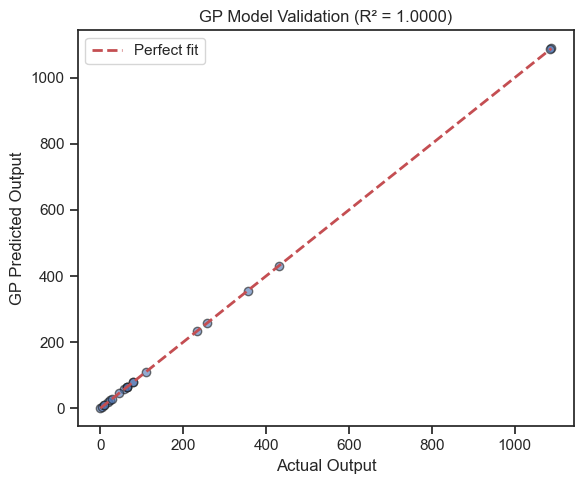

In [10]:
# Predict on training data
y_pred_scaled, y_std_scaled = gp.predict(X_scaled, return_std=True)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_std = y_std_scaled * scaler_y.scale_

# Calculate R² score
from sklearn.metrics import r2_score
r2 = r2_score(y, y_pred)
print(f"R² score: {r2:.4f}")

# Minimal visualization: Predicted vs Actual
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Output')
plt.ylabel('GP Predicted Output')
plt.title(f'GP Model Validation (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()


## Analysis and recommendation

Since we know that the function has only one peak, we will run a strategy of exploitation around the best observed peak, by perturbing one variable at a time. This strategy requires us to get several more data points over the coming weeks before getting a good understanding of the local shape of the function. By systematically varying one variable while keeping others fixed, we can map out the local landscape around the peak and refine our understanding of the optimal region. We note that the current best value shows high values for x2-x4 and a low value for x1. x1 thus appears as a good starting point to see if increasing x1 increases y. Our recommended point is: x1 = 0.191447	x2 = 0.846480	x3 = 0.879484	x4 = 0.878516.

In [13]:
from scipy.optimize import differential_evolution

# Define objective: negative GP mean (to maximize mean, we minimize negative mean)
def negative_gp_mean(x):
    x_scaled = scaler_X.transform(x.reshape(1, -1))
    mu_scaled = gp.predict(x_scaled, return_std=False)
    mu = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()[0]
    return -mu

# Optimize over [0, 1]^4
bounds = [(0, 1)] * 4
result = differential_evolution(negative_gp_mean, bounds, seed=42, maxiter=1000, atol=1e-7, tol=1e-7)

# Extract recommended point
x_next = result.x
y_next_pred = -result.fun

print("=" * 60)
print("RECOMMENDED NEXT POINT (Pure Exploitation via GP Mean)")
print("=" * 60)
print(f"x1 = {x_next[0]:.6f}")
print(f"x2 = {x_next[1]:.6f}")
print(f"x3 = {x_next[2]:.6f}")
print(f"x4 = {x_next[3]:.6f}")
print(f"\nPredicted output: {y_next_pred:.2f}")
print(f"Current best observed: {y.max():.2f} (at observation {y.argmax()})")
print("=" * 60)


RECOMMENDED NEXT POINT (Pure Exploitation via GP Mean)
x1 = 0.202624
x2 = 0.849188
x3 = 0.971974
x4 = 0.920186

Predicted output: 1161.37
Current best observed: 1088.86 (at observation 15)


## Summary

**Strategy:** Pure exploitation via GP mean maximization

**Rationale:**
- Function 5 is confirmed unimodal with a single peak
- We have 21 observations with several near the optimum
- The GP model shows good fit (high R²), giving us confidence in its predictions
- Maximizing the GP mean prediction focuses sampling precisely where the model predicts the highest yield

**Next Steps:**
- Submit the recommended point above
- Continue exploitation in subsequent weeks to refine the peak estimate
- Monitor if predictions remain accurate as we gather more data
